# Social Discounting

## Task

On every trial, the participant chooses between two options:

- **Selfish**: keep the whole pot, the target gets nothing.
- **Prosocial**: split the pot with the target.

The same 9-trial payout ladder repeats at each of 7 social distances,
`N = [1, 2, 5, 10, 20, 50, 100]` (1 = closest, e.g. a partner or close
friend; 100 = most distant, e.g. a stranger), for 7 blocks x 9 trials = 63
trials total per subject.

**TASK1** holds the prosocial split fixed at $r_{\text{self}}=75$, $r_{\text{other}}=75$,
and steps the selfish option's $r_{\text{self}}$ down from \$155 to \$75 across the 9
trials. The "cost" of choosing prosocial over selfish shrinks from \$80 (give
up \$155 for \$75) to \$0 (the two options are identical) as the ladder
descends.

**TASK2** holds the prosocial split fixed at $r_{\text{self}}=0$, $r_{\text{other}}=105$
(choosing prosocial always means giving up everything yourself), and steps
the selfish option's $r_{\text{self}}$ down from \$95 to \$15. Unlike TASK1, the
prosocial option here never benefits the chooser at all; only the
opportunity cost of staying selfish shrinks.

Below, `payouts[trial, choice, target]` with `choice = 0` selfish / `1`
prosocial, and `target = 0` self / `1` other -- i.e. `payouts[..., 0]` is
$r_{\text{self}}$ and `payouts[..., 1]` is $r_{\text{other}}$ for that option.

## Model

On each trial, the value of an option is the chooser's own payout $r_{\text{self}}$
plus a (weighted, distance-discounted) value of the target's payout $r_{\text{other}}$:

$$
\textbf{Self utility:}\quad U_{\text{self}} = r_{\text{self}}
$$

$$
\textbf{Weighted target reward:}\quad R = w_{\text{other}} \cdot r_{\text{other}}
$$

$w_{\text{other}}$ is an **other-regarding weight** ($w_{\text{other}}=1$ values the
target's dollar the same as the chooser's own, $<1$ undervalues it, $>1$
overvalues it; fixed at 1 except in `sd_hyp_wk`, where it's free). $R$ is
then discounted as a function of social distance $N$, using one of three
shapes:

$$
\textbf{Hyperbolic:}\quad U_{\text{other}}(N) = \frac{R}{1+kN}
$$

$$
\textbf{Linear:}\quad U_{\text{other}}(N) = R - kN \quad \text{(only where } R>0\text{, else } 0\text{)}
$$

$$
\textbf{Parabolic:}\quad U_{\text{other}}(N) = R - kN^2 \quad \text{(only where } R>0\text{, else } 0\text{)}
$$

The "only where $R>0$" clause matters: the selfish option always has
$r_{\text{other}}=0$, so $R=0$ for it regardless of $N$. Hyperbolic discounting
handles this for free ($0/\text{anything}=0$), but a bare subtractive form
would inject a $-kN$ penalty into the selfish option too, which cancels out
of the option comparison below and makes $N$ irrelevant to choice. Gating
the subtraction on $R>0$ keeps "nothing offered" equal to "nothing
discounted" for every shape.

Total option value: $V = U_{\text{self}} + U_{\text{other}}$.

$$
\textbf{Choice rule (logistic / sigmoid):}\quad
p(\text{prosocial}) = \sigma\big(\Delta V\big) = \frac{1}{1+e^{-\left(V_{\text{prosocial}} - V_{\text{selfish}}\right)}}
$$

This is the standard logistic choice function used in the discounting
literature (equivalent to a two-option softmax with unit temperature): there
is **no free inverse temperature**. Since the selfish option always offers
the target nothing, the comparison reduces to

$$
\Delta V = \frac{w_{\text{other}} \cdot r_{\text{other}}}{1+kN} - r_{\text{self}}
$$

for the hyperbolic models, where $r_{\text{self}}$ here is the selfish
option's own payout minus the prosocial option's own payout.

Four model variants are defined in `pyem/models/social_discounting.py`:

| model | discount shape | free parameters |
|---|---|---|
| `sd_hyp_wk` | hyperbolic | $w_{\text{other}}$, $k$ |
| `sd_hyp_k`  | hyperbolic | $k$ ($w_{\text{other}}=1$) |
| `sd_par_k`  | parabolic  | $k$ ($w_{\text{other}}=1$) |
| `sd_lin_k`  | linear     | $k$ ($w_{\text{other}}=1$) |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import truncnorm
from scipy.special import expit

from pyem import EMModel
from pyem.utils.math import norm2beta
from pyem.utils import plotting

from pyem.models.social_discounting import (
    TASK1_PAYOUTS,
    TASK2_PAYOUTS,
    DEFAULT_SOCIAL_DISTS,
    sd_hyp_wk_model, sd_hyp_k_model, sd_par_k_model, sd_lin_k_model,
)

rng = np.random.default_rng(2026)

def draw_positive(n, lo, hi, loc=0.0, scale=1.0):
    # truncated-normal draw restricted to [lo, hi]
    a = (lo - loc) / scale
    b = (hi - loc) / scale
    return truncnorm(a, b, loc=loc, scale=scale).rvs(n, random_state=rng)

# choose task for the recovery runs below
payouts = TASK1_PAYOUTS.copy()
# payouts = TASK2_PAYOUTS.copy()

social_dists = DEFAULT_SOCIAL_DISTS.copy()
nsubjects = 100

# k ranges differ by discount shape: N reaches 100, and k*N (linear) or
# k*N**2 (parabolic) both need to land in roughly the same dollar range as
# the payouts themselves (~0-150) for the discount to actually bite without
# saturating every trial's choice probability.
wmin, wmax = 0.2, 2.0
k_ranges = {
    "hyperbolic": (0.001, 0.25),
    "linear":     (0.05, 1.5),
    "parabolic":  (0.0005, 0.015),
}
k_scales = {
    "hyperbolic": 0.08,
    "linear":     0.5,
    "parabolic":  0.005,
}

## Hyperbolic discounting, 2 parameters ($w_{\text{other}}$, $k$) — `sd_hyp_wk`

$$
V = r_{\text{self}} + \frac{w_{\text{other}} \cdot r_{\text{other}}}{1+kN}, \qquad p(\text{prosocial}) = \sigma\big(V_{\text{prosocial}} - V_{\text{selfish}}\big)
$$

In [34]:
print(f"Model ID   : {sd_hyp_wk_model.id}")
print(f"Description: {sd_hyp_wk_model.desc}")
print(f"Spec       : {sd_hyp_wk_model.spec}")

Model ID   : sd_hyp_wk
Description: Hyperbolic social discounting: U_other(N) = w_other*r_other / (1 + k*N).
The other-regarding weight is applied to the target's payoff, then discounted
hyperbolically as a function of social distance N.
p(prosocial) = sigmoid(V_prosocial - V_selfish).
Free parameters: w_other (other-regarding weight, >0), k (hyperbolic discount rate, >0).
Spec       : {'social_discounting': {'weight': ['w_other'], 'discount': ['k']}, 'shape': 'hyperbolic', 'choice_rule': 'sigmoid(delta_V)'}


805.2258 (000), 384.2362 (001), 353.3634 (002), 352.5961 (003), 352.5358 (004), 352.5187 (005), 352.5185 (007), 

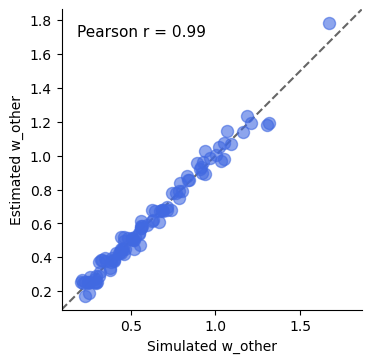

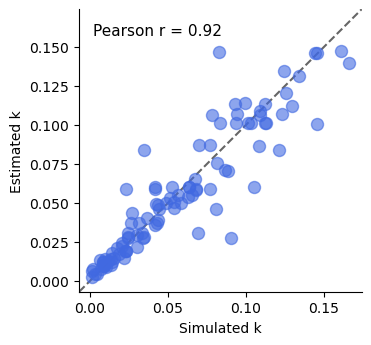

In [35]:
kmin, kmax = k_ranges["hyperbolic"]
true_w_other = draw_positive(nsubjects, wmin, wmax, loc=0.0, scale=0.6)
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=k_scales["hyperbolic"])
true_params = np.stack([true_w_other, true_k], axis=1)

sim = sd_hyp_wk_model.sim(true_params, payouts=payouts, social_dists=social_dists)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

model = EMModel(
    all_data=all_data,
    fit_func=sd_hyp_wk_model.fit,
    param_names=["w_other", "k"],
    param_xform=[norm2beta, norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["w_other", "k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Diagnostic plots: the fitted value difference ($\Delta V$ = prosocial minus
selfish) and the discounted utility of the target's payout ($U_{\text{other}}$),
as a function of social distance $N$ and the selfish option's own payout
$r_{\text{self}}$. (Built from `TASK1_PAYOUTS`; swap in `TASK2_PAYOUTS` if you
changed `payouts` above.)

In [42]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "social distance (N)": np.repeat(model.outfit['social_dists'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (prosocial - selfish)": model.outfit['delta_V'].reshape(-1),
    "prosocial choice": model.outfit['choices_prosocial'].reshape(-1),
    "utility (other)": model.outfit['U_other'].reshape(-1),
    "r_self": np.tile(TASK1_PAYOUTS[:, 0, 0, ...], nsubjects * nblocks),
    "p(prosocial)": model.outfit['p_prosocial'].reshape(-1),
})

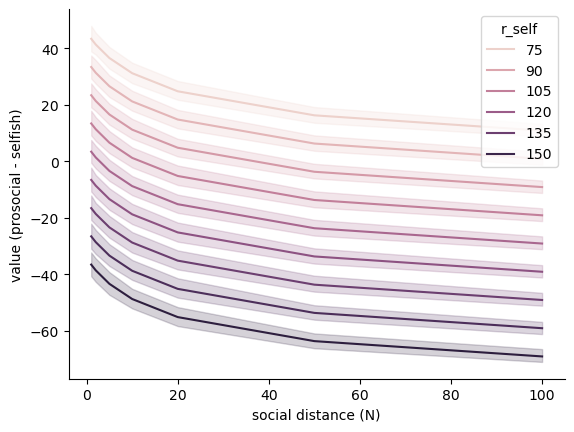

In [43]:
sns.lineplot(data=df, x='social distance (N)', y='value (prosocial - selfish)', hue='r_self')
sns.despine()

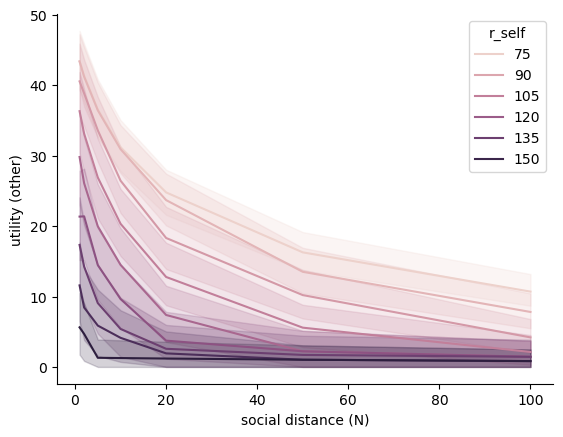

In [44]:
sns.lineplot(data=df, y='utility (other)', x='social distance (N)', hue='r_self')
sns.despine()

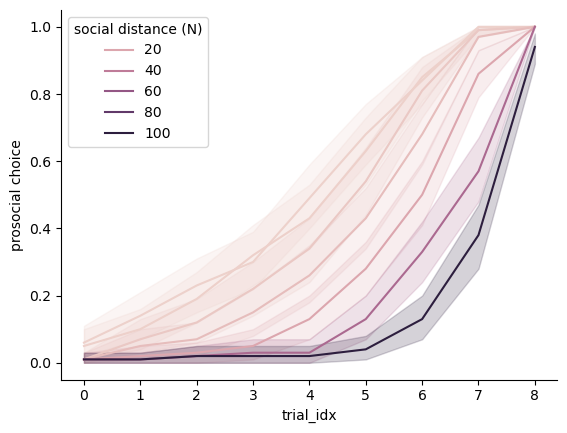

In [45]:
sns.lineplot(x='trial_idx', y='prosocial choice', hue='social distance (N)', data=df)
sns.despine()

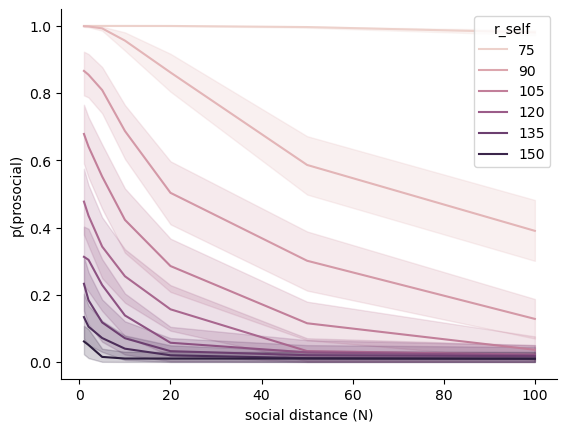

In [46]:
sns.lineplot(data=df, y='p(prosocial)', x='social distance (N)', hue='r_self')
sns.despine()

<hr width="80%">

## Hyperbolic discounting, 1 parameter ($k$; $w_{\text{other}}=1$) — `sd_hyp_k`

$$
V = r_{\text{self}} + \frac{r_{\text{other}}}{1+kN}, \qquad p(\text{prosocial}) = \sigma\big(V_{\text{prosocial}} - V_{\text{selfish}}\big)
$$

In [47]:
print(f"Model ID   : {sd_hyp_k_model.id}")
print(f"Description: {sd_hyp_k_model.desc}")
print(f"Spec       : {sd_hyp_k_model.spec}")

Model ID   : sd_hyp_k
Description: Hyperbolic social discounting: U_other(N) = r_other / (1 + k*N).
The target's payoff is discounted hyperbolically as a function of social
distance N (w_other fixed at 1). p(prosocial) = sigmoid(V_prosocial - V_selfish).
Free parameter: k (hyperbolic discount rate, >0).
Spec       : {'social_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'hyperbolic', 'choice_rule': 'sigmoid(delta_V)'}


528.6076 (000), 399.0643 (001), 315.7275 (002), 315.1094 (003), 315.1059 (004), 315.1057 (005), 

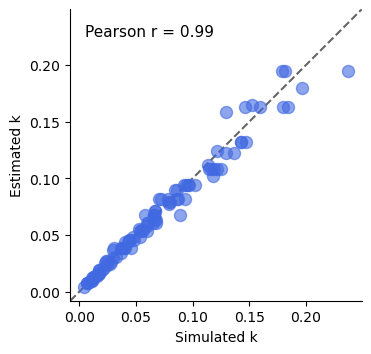

In [48]:
kmin, kmax = k_ranges["hyperbolic"]
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=k_scales["hyperbolic"])
true_params = np.stack([true_k], axis=1)

sim = sd_hyp_k_model.sim(true_params, payouts=payouts, social_dists=social_dists)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

model = EMModel(
    all_data=all_data,
    fit_func=sd_hyp_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

Same diagnostic plots as above, run on this recovery.

In [50]:
_, nblocks, ntrials = model.outfit['delta_V'].shape
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "social distance (N)": np.repeat(model.outfit['social_dists'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (prosocial - selfish)": model.outfit['delta_V'].reshape(-1),
    "prosocial choice": model.outfit['choices_prosocial'].reshape(-1),
    "utility (other)": model.outfit['U_other'].reshape(-1),
    "r_self": np.tile(TASK1_PAYOUTS[:, 0, 0, ...], nsubjects * nblocks),
    "p(prosocial)": model.outfit['p_prosocial'].reshape(-1),
})

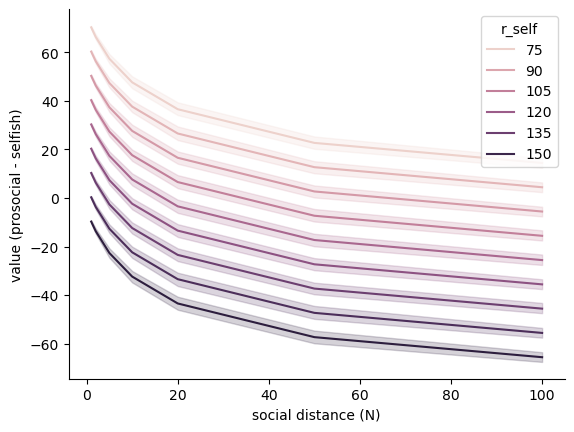

In [51]:
sns.lineplot(data=df, x='social distance (N)', y='value (prosocial - selfish)', hue='r_self')
sns.despine()

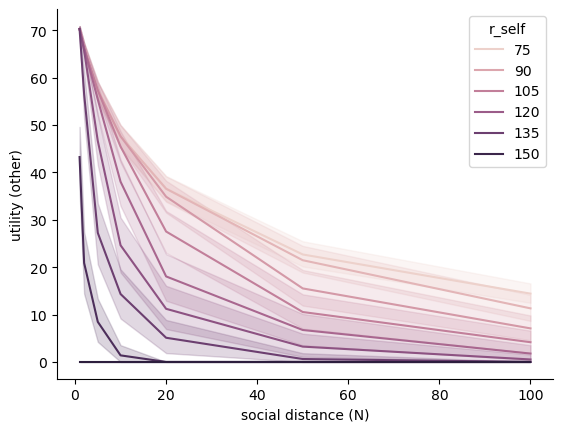

In [52]:
sns.lineplot(data=df, y='utility (other)', x='social distance (N)', hue='r_self')
sns.despine()

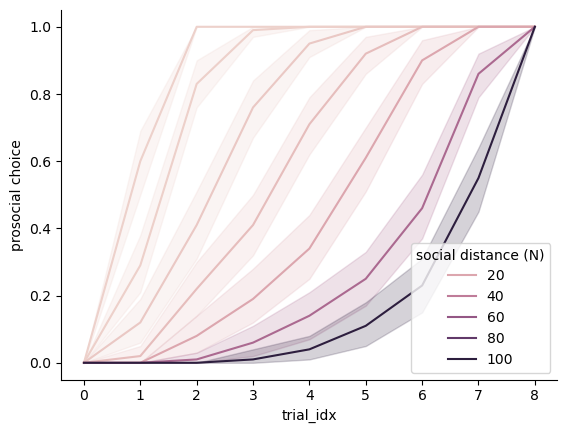

In [53]:
sns.lineplot(x='trial_idx', y='prosocial choice', hue='social distance (N)', data=df)
sns.despine()

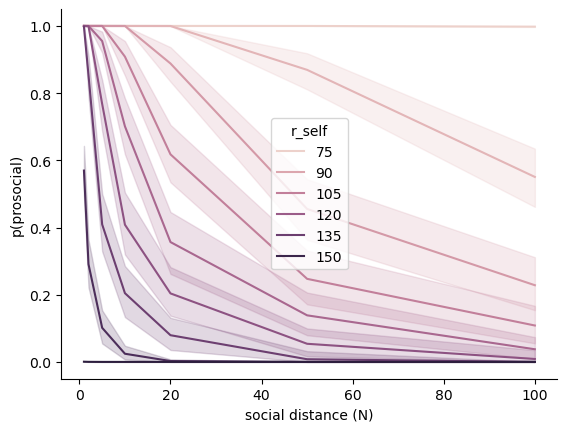

In [55]:
sns.lineplot(data=df, y='p(prosocial)', x='social distance (N)', hue='r_self')
sns.despine()

<hr width="80%">

## Parabolic discounting, 1 parameter ($k$; $w_{\text{other}}=1$) — `sd_par_k`

$$
U_{\text{other}}(N) = r_{\text{other}} - kN^2 \quad \text{(only where } r_{\text{other}} > 0\text{)}, \qquad p(\text{prosocial}) = \sigma\big(V_{\text{prosocial}} - V_{\text{selfish}}\big)
$$

$N^2$ grows fast (up to $100^2=10{,}000$ at the farthest distance), so $k$
here needs to be roughly two orders of magnitude smaller than in the linear
model to produce a comparable amount of discounting.

In [56]:
print(f"Model ID   : {sd_par_k_model.id}")
print(f"Description: {sd_par_k_model.desc}")
print(f"Spec       : {sd_par_k_model.spec}")

Model ID   : sd_par_k
Description: Parabolic social discounting: U_other(N) = r_other - k*N**2 (for the
option that actually offers the target something; 0 for the selfish option,
regardless of N; w_other fixed at 1). p(prosocial) = sigmoid(V_prosocial - V_selfish).
Because N**2 grows fast, k must be much smaller than in the linear model to
produce comparable discounting over the same N range.
Free parameter: k (parabolic discount rate, >0).
Spec       : {'social_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'parabolic', 'choice_rule': 'sigmoid(delta_V)'}


452.6140 (000), 250.5570 (001), 191.7187 (002), 190.2781 (003), 190.1939 (004), 190.1834 (005), 190.1820 (006), 190.1817 (007), 

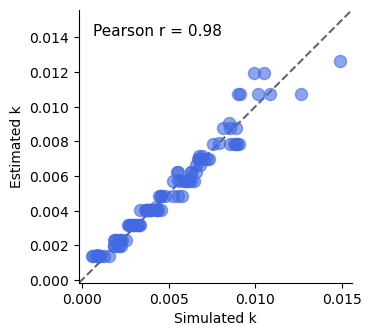

In [57]:
kmin, kmax = k_ranges["parabolic"]
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=k_scales["parabolic"])
true_params = np.stack([true_k], axis=1)

sim = sd_par_k_model.sim(true_params, payouts=payouts, social_dists=social_dists)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

model = EMModel(
    all_data=all_data,
    fit_func=sd_par_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

<hr width="80%">

## Linear discounting, 1 parameter ($k$; $w_{\text{other}}=1$) — `sd_lin_k`

$$
U_{\text{other}}(N) = r_{\text{other}} - kN \quad \text{(only where } r_{\text{other}} > 0\text{)}, \qquad p(\text{prosocial}) = \sigma\big(V_{\text{prosocial}} - V_{\text{selfish}}\big)
$$

In [58]:
print(f"Model ID   : {sd_lin_k_model.id}")
print(f"Description: {sd_lin_k_model.desc}")
print(f"Spec       : {sd_lin_k_model.spec}")

Model ID   : sd_lin_k
Description: Linear social discounting: U_other(N) = r_other - k*N (for the option
that actually offers the target something; 0 for the selfish option,
regardless of N; w_other fixed at 1). p(prosocial) = sigmoid(V_prosocial - V_selfish).
Utility is not floored at zero, so heavily-discounted prosocial offers can
carry negative utility at large N.
Free parameter: k (linear discount rate, >0).
Spec       : {'social_discounting': {'weight': [], 'discount': ['k']}, 'shape': 'linear', 'choice_rule': 'sigmoid(delta_V)'}


446.8017 (000), 238.3838 (001), 234.2697 (002), 234.0697 (003), 234.0482 (004), 234.0448 (005), 234.0442 (006), 

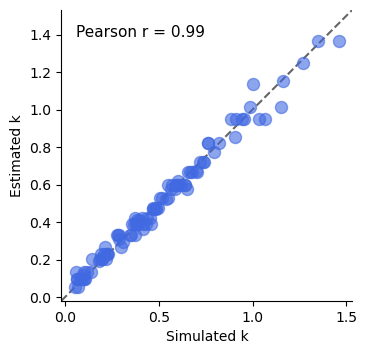

In [59]:
kmin, kmax = k_ranges["linear"]
true_k = draw_positive(nsubjects, kmin, kmax, loc=0.0, scale=k_scales["linear"])
true_params = np.stack([true_k], axis=1)

sim = sd_lin_k_model.sim(true_params, payouts=payouts, social_dists=social_dists)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

model = EMModel(
    all_data=all_data,
    fit_func=sd_lin_k_model.fit,
    param_names=["k"],
    param_xform=[norm2beta],
)

result = model.fit(verbose=1)

for param_idx, param_label in enumerate(["k"]):
    simulated_param = sim["params"][:, param_idx]
    estimated_param = model.outfit["params"][:, param_idx]
    ax = plotting.plot_scatter(simulated_param, f"Simulated {param_label}",
                                estimated_param, f"Estimated {param_label}")

**References**

Jones, B., & Rachlin, H. (2006). Social discounting. Psychological Science, 17(4), 283-286.

Rhoads, S. A., Vekaria, K. M., O'Connell, K., Elizabeth, H. S., Rand, D. G., Kozak Williams, M. N., & Marsh, A. A. (2023). Unselfish traits and social decision-making patterns characterize six populations of real-world extraordinary altruists. Nature Communications, 14(1), 1807.

Rhoads, S. A., O'Connell, K., Berluti, K., Ploe, M. L., Elizabeth, H. S., Amormino, P., ... & Marsh, A. A. (2023). Neural responses underlying extraordinary altruists' generosity for socially distant others. PNAS nexus, 2(7), pgad199.